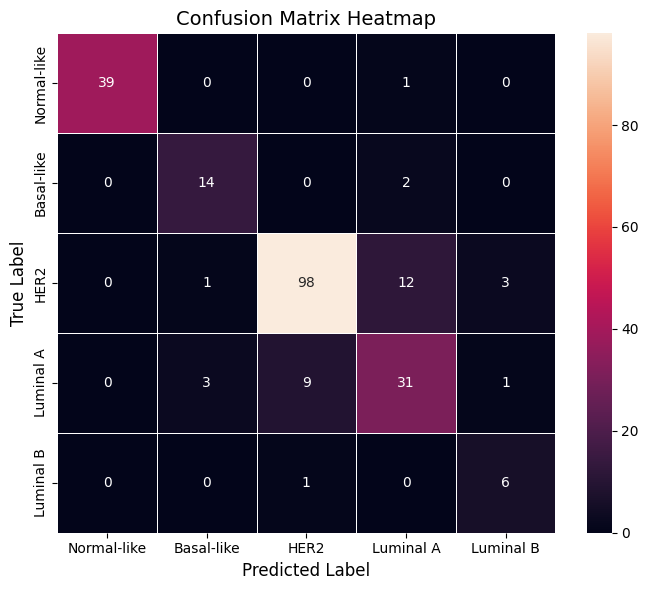

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
# Confusion matrix
cm = np.array([
[39, 0, 0, 1, 0],
[0, 14, 0, 2, 0],
[0, 1, 98, 12, 3],
[0, 3, 9, 31, 1],
[0, 0, 1, 0, 6]
])

# Class labels (modify if needed)
labels = ["Normal-like", "Basal-like", "HER2", "Luminal A", "Luminal B"]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    linewidths=0.5
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

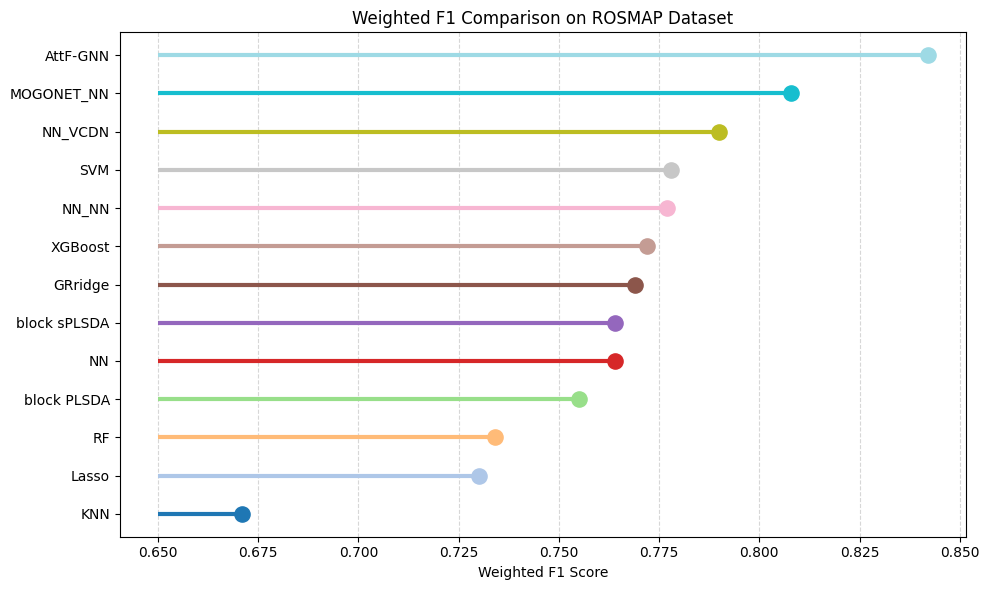

In [8]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
"KNN","SVM","Lasso","RF","XGBoost","NN","GRridge",
"block PLSDA","block sPLSDA","NN_NN","NN_VCDN","MOGONET_NN", "AttF-GNN"
]

f1_scores = [
0.671,0.778,0.730,0.734,0.772,0.764,
0.769,0.755,0.764,0.777,0.790,0.808, 0.842
]

# Sort methods by score
data = sorted(zip(methods, f1_scores), key=lambda x: x[1])
methods_sorted, scores_sorted = zip(*data)

y = np.arange(len(methods_sorted))

# Create a color palette
colors = plt.cm.tab20(np.linspace(0,1,len(methods_sorted)))

plt.figure(figsize=(10,6))

for i in range(len(methods_sorted)):
    
    # lollipop stick
    plt.hlines(
        y=y[i],
        xmin=0.65,
        xmax=scores_sorted[i],
        color=colors[i],
        linewidth=3
    )
    
    # lollipop head
    plt.scatter(
        scores_sorted[i],
        y[i],
        s=120,
        color=colors[i]
    )

plt.yticks(y, methods_sorted)
plt.xlabel("Weighted F1 Score")
plt.title("Weighted F1 Comparison on ROSMAP Dataset")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

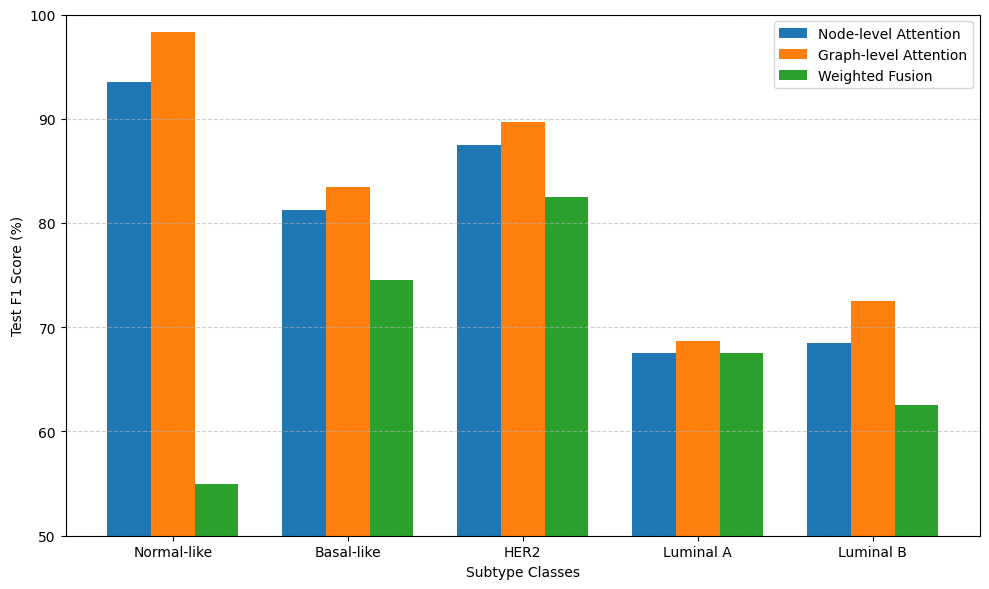

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Data
classes = ['Normal-like','Basal-like','HER2','Luminal A','Luminal B']

node_attention = [93.50,81.25,87.46,67.56,68.45]
graph_attention = [98.30,83.50,89.66,68.68,72.50]
weighted_fusion = [55.00,74.50,82.50,67.50,62.50]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, node_attention, width, label='Node-level Attention')
plt.bar(x, graph_attention, width, label='Graph-level Attention')
plt.bar(x + width, weighted_fusion, width, label='Weighted Fusion')

plt.xticks(x, classes)
plt.ylabel('Test F1 Score (%)')
plt.xlabel('Subtype Classes')


plt.ylim(50,100)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()